Load data

In [1]:
import pandas as pd
train_csv =pd.read_csv('train.csv')
train_csv.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Identify missing values

In [5]:
missing_percentage = round((train_csv.isnull().sum() / len(train_csv)) * 100, 2)
missing_percentage

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

Compute the median 

In [12]:

train_csv['Age'] = train_csv['Age'].fillna(train_csv['Age'].median())
train_csv['Age'].head(10)


0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
5    28.0
6    54.0
7     2.0
8    27.0
9    14.0
Name: Age, dtype: float64

Compute the mode

In [16]:

train_csv['Embarked'] = train_csv['Embarked'].fillna(train_csv['Embarked'].mode())
train_csv['Embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

compute the missing Values

In [19]:

train_csv['Cabin_Missing'] = train_csv['Cabin'].isnull().astype(int)
train_csv['Deck'] = train_csv['Cabin'].str[0]
train_csv['Cabin']

0       NaN
1       C85
2       NaN
3      C123
4       NaN
       ... 
886     NaN
887     B42
888     NaN
889    C148
890     NaN
Name: Cabin, Length: 891, dtype: object

Visializing Age and Fare outlires

In [20]:
import matplotlib.pyplot as plt

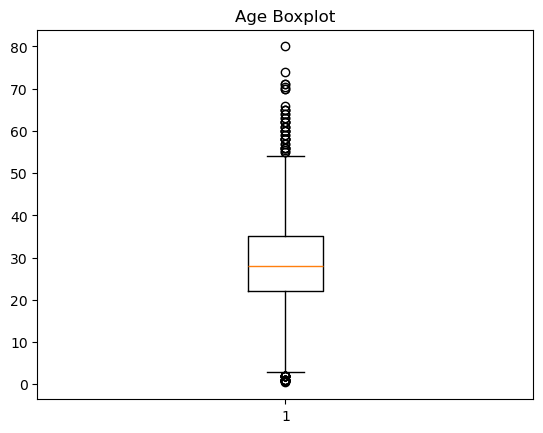

In [21]:
plt.boxplot(train_csv['Age'].dropna())
plt.title('Age Boxplot')
plt.show()

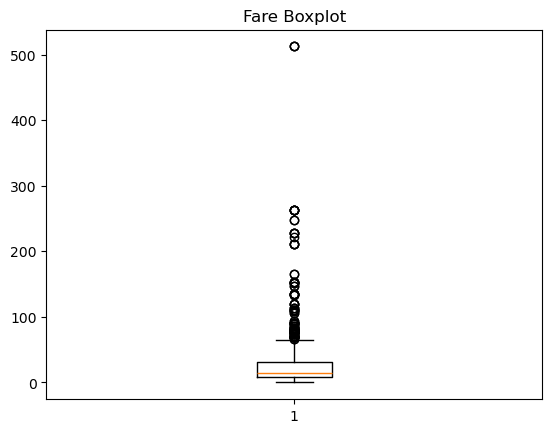

In [11]:
import matplotlib.pyplot as plt
plt.boxplot(train_csv['Fare'].dropna())
plt.title('Fare Boxplot')
plt.show()

In [14]:
def remove_outliers_iqr(csv, column):
    Q1 = csv[column].quantile(0.25)
    Q3 = csv[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return csv[(csv[column] >= lower_bound) & (csv[column] <= upper_bound)]

# Apply to Age and Fare
train_csv = remove_outliers_iqr(train_csv, 'Age')
train_csv = remove_outliers_iqr(train_csv, 'Fare')

In [16]:
print(train_csv['Sex'].unique())  # Should be ['male', 'female']
print(train_csv['Embarked'].unique())  # Should be ['C', 'Q', 'S']

# Remove duplicates
train_csv.drop_duplicates(inplace=True)

['male' 'female']
['S' 'C' 'Q']


In [17]:
train_csv.to_csv('data/train_cleaned.csv', index=False)

Creating FamilySize

In [20]:
# Create FamilySize feature
train_csv['FamilySize'] = train_csv['SibSp'] + train_csv['Parch'] + 1

# Display the head with the new feature
display(train_csv[['SibSp', 'Parch', 'FamilySize']].head())

,SibSp,Parch,FamilySize
0,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
6,0,0,1


Creating IsAlone

In [21]:
# Create IsAlone feature
train_csv['IsAlone'] = 0
train_csv.loc[train_csv['FamilySize'] == 1, 'IsAlone'] = 1

# Display the head with the new feature
display(train_csv[['FamilySize', 'IsAlone']].head())

,FamilySize,IsAlone
0,2,0
2,1,1
3,2,0
4,1,1
6,1,1


Title extraction from Name

In [22]:
import re

def get_title(name):
    title_search = re.search(r' ([A-Za-z]+)\.', name)
    if title_search:
        return title_search.group(1)
    return ""

# Apply the function to extract titles
train_csv['Title'] = train_csv['Name'].apply(get_title)

# Standardize known title variations
train_csv['Title'] = train_csv['Title'].replace('Mlle', 'Miss')
train_csv['Title'] = train_csv['Title'].replace('Ms', 'Miss')
train_csv['Title'] = train_csv['Title'].replace('Mme', 'Mrs')

print("Title counts after initial extraction and standardization:")
print(train_csv['Title'].value_counts())


Title counts after initial extraction and standardization:
Title
Mr          337
Miss        109
Mrs          79
Master       33
Rev           6
Dr            4
Major         2
Col           2
Don           1
Lady          1
Jonkheer      1
Name: count, dtype: int64


In [23]:
# Define a threshold for 'rare' titles
threshold = 10

# Identify titles that are less frequent than the threshold
rare_titles = train_csv['Title'].value_counts()[train_csv['Title'].value_counts() < threshold].index.tolist()

# Apply the programmatic grouping if rare titles are found
if rare_titles:
    train_csv['Title'] = train_csv['Title'].replace(rare_titles, 'Rare')
    print(f"Grouped {len(rare_titles)} titles into 'Rare' (threshold={threshold}).")
else:
    print(f"No additional titles found to be rare with threshold={threshold}. 'Title' column remains unchanged.")

# Display the final count of each title
print("\nFinal Title counts after programmatic grouping:")
print(train_csv['Title'].value_counts())
display(train_csv[['Name', 'Title']].head())

Grouped 7 titles into 'Rare' (threshold=10).

Final Title counts after programmatic grouping:
Title
Mr        337
Miss      109
Mrs        79
Master     33
Rare       17
Name: count, dtype: int64


,Name,Title
0,"Braund, Mr. Owen Harris",Mr
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr
6,"McCarthy, Mr. Timothy J",Mr


Creating AgeGroup

In [24]:
# Create AgeGroup feature
def create_age_group(age):
    if age <= 12:
        return 'Child'
    elif age <= 18:
        return 'Teen'
    elif age <= 60:
        return 'Adult'
    else:
        return 'Senior'

train_csv['AgeGroup'] = train_csv['Age'].apply(create_age_group)

# Display the head with the new feature and its value counts
print("AgeGroup Value Counts:")
print(train_csv['AgeGroup'].value_counts())
display(train_csv[['Age', 'AgeGroup']].head())

AgeGroup Value Counts:
AgeGroup
Adult    452
Child     65
Teen      58
Name: count, dtype: int64


,Age,AgeGroup
0,22.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult
6,54.0,Adult


Creating FarePerPerson

In [25]:
# Create FarePerPerson feature
train_csv['FarePerPerson'] = train_csv['Fare'] / train_csv['FamilySize']

# Display the head with the new feature
display(train_csv[['Fare', 'FamilySize', 'FarePerPerson']].head())
train_csv.head()

,Fare,FamilySize,FarePerPerson
0,7.2500,2,3.6250
2,7.9250,1,7.9250
3,53.1000,2,26.5500
4,8.0500,1,8.0500
6,51.8625,1,51.8625


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,Title,AgeGroup,FarePerPerson
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,Mr,Adult,3.6250
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,Miss,Adult,7.9250
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,Mrs,Adult,26.5500
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1,Mr,Adult,8.0500
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,1,1,Mr,Adult,51.8625


Categorical Encoding

In [26]:

# Identify categorical columns to be one-hot encoded
categorical_cols = ['Sex', 'Embarked', 'Title', 'AgeGroup', 'Pclass']

# Apply one-hot encoding
train_csv_encoded = pd.get_dummies(train_csv, columns=categorical_cols, drop_first=True, dtype=int)

# Display the first few rows of the encoded DataFrame
print("Shape of DataFrame before encoding:", train_csv.shape)
print("Shape of DataFrame after encoding:", train_csv_encoded.shape)
print("\nFirst 5 rows of the encoded DataFrame:")
display(train_csv_encoded.head())

Shape of DataFrame before encoding: (575, 17)
Shape of DataFrame after encoding: (575, 23)

First 5 rows of the encoded DataFrame:


,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,FamilySize,...,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_Child,AgeGroup_Teen,Pclass_2,Pclass_3
0,1,0,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,2,...,0,1,0,1,0,0,0,0,0,1
2,3,1,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,1,...,0,1,1,0,0,0,0,0,0,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,2,...,0,1,0,0,1,0,0,0,0,0
4,5,0,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,1,...,0,1,0,1,0,0,0,0,0,1
6,7,0,"McCarthy, Mr. Timothy J",54.0,0,0,17463,51.8625,E46,1,...,0,1,0,1,0,0,0,0,0,0


Create Age_Title Interaction Features

In [27]:
# Identify the one-hot encoded Title columns
title_encoded_cols = [col for col in train_csv_encoded.columns if col.startswith('Title_')]

# Create interaction features for Age and each Title category
for title_col in title_encoded_cols:
    new_col_name = f"Age_x_{title_col}"
    train_csv_encoded[new_col_name] = train_csv_encoded['Age'] * train_csv_encoded[title_col]

print("Generated Age-Title interaction features.")
# Display the head with the new features, including Age and some Title interaction features
display(train_csv_encoded[['Age'] + title_encoded_cols + [f'Age_x_{col}' for col in title_encoded_cols]].head())

Generated Age-Title interaction features.


,Age,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Age_x_Title_Miss,Age_x_Title_Mr,Age_x_Title_Mrs,Age_x_Title_Rare
0,22.0,0,1,0,0,0.0,22.0,0.0,0.0
2,26.0,1,0,0,0,26.0,0.0,0.0,0.0
3,35.0,0,0,1,0,0.0,0.0,35.0,0.0
4,35.0,0,1,0,0,0.0,35.0,0.0,0.0
6,54.0,0,1,0,0,0.0,54.0,0.0,0.0


Craeting Pclas_Fare Interaction Features

In [28]:
# Create Pclass-Fare Interaction Features
train_csv_encoded['Fare_x_Pclass_2'] = train_csv_encoded['Fare'] * train_csv_encoded['Pclass_2']
train_csv_encoded['Fare_x_Pclass_3'] = train_csv_encoded['Fare'] * train_csv_encoded['Pclass_3']

print("Generated Pclass-Fare interaction features.")
# Display the head with the new features, including Fare and Pclass interaction features
display(train_csv_encoded[['Fare', 'Pclass_2', 'Pclass_3', 'Fare_x_Pclass_2', 'Fare_x_Pclass_3']].head())

Generated Pclass-Fare interaction features.


,Fare,Pclass_2,Pclass_3,Fare_x_Pclass_2,Fare_x_Pclass_3
0,7.2500,0,1,0.0,7.250
2,7.9250,0,1,0.0,7.925
3,53.1000,0,0,0.0,0.000
4,8.0500,0,1,0.0,8.050
6,51.8625,0,0,0.0,0.000


Feature Transformations - Identifying Skewed Features

Numerical features to check for skewness: ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'FarePerPerson', 'Fare_x_Pclass_2', 'Fare_x_Pclass_3', 'Age_x_Title_Miss', 'Age_x_Title_Mr', 'Age_x_Title_Mrs', 'Age_x_Title_Rare']


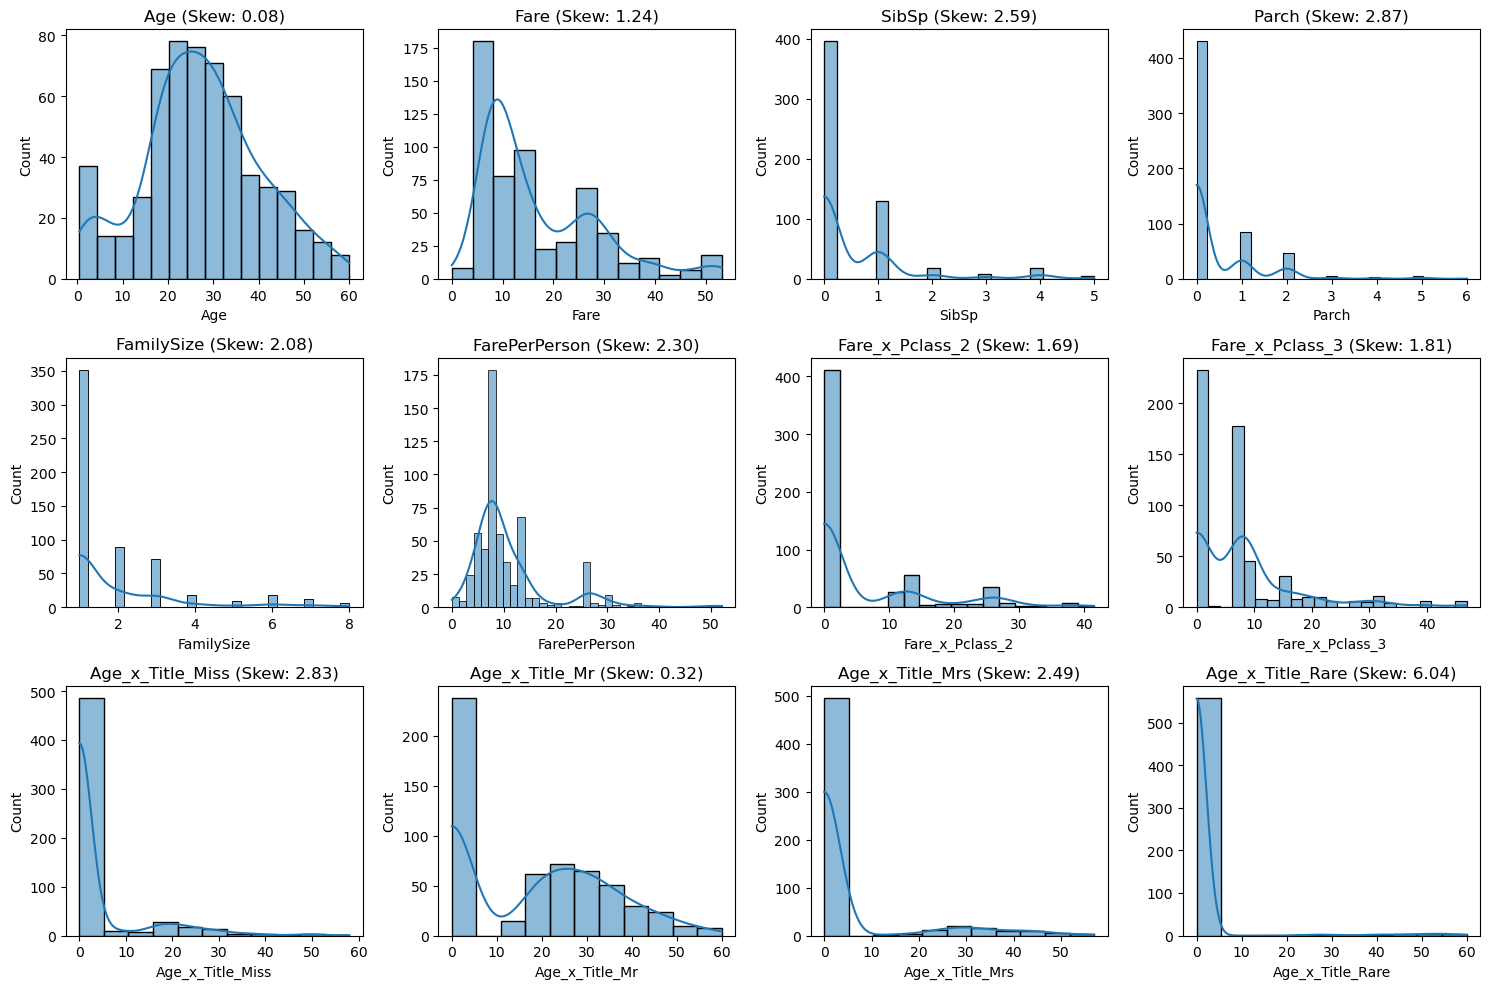


Skewness of numerical features:
 Age_x_Title_Rare    6.037888
Parch               2.866271
Age_x_Title_Miss    2.825033
SibSp               2.594632
Age_x_Title_Mrs     2.485113
FarePerPerson       2.303224
FamilySize          2.079525
Fare_x_Pclass_3     1.812224
Fare_x_Pclass_2     1.694473
Fare                1.244889
Age_x_Title_Mr      0.322904
Age                 0.082993
dtype: float64

Features with absolute skewness > 0.75: ['Age_x_Title_Rare', 'Parch', 'Age_x_Title_Miss', 'SibSp', 'Age_x_Title_Mrs', 'FarePerPerson', 'FamilySize', 'Fare_x_Pclass_3', 'Fare_x_Pclass_2', 'Fare']


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Identify numerical columns (excluding PassengerId and Survived, which are identifiers/target)
numerical_cols = [
    'Age',
    'Fare',
    'SibSp',
    'Parch',
    'FamilySize',
    'FarePerPerson',
    'Fare_x_Pclass_2',
    'Fare_x_Pclass_3'
]

# Add Age-Title interaction features to the list
# We need to make sure these columns exist before adding them
age_title_interaction_cols = [col for col in train_csv_encoded.columns if col.startswith('Age_x_Title_')]
numerical_cols.extend(age_title_interaction_cols)

# Filter to ensure only columns present in train_df_encoded are included
numerical_cols_present = [col for col in numerical_cols if col in train_csv_encoded.columns]

print("Numerical features to check for skewness:", numerical_cols_present)

# Plot distributions and calculate skewness
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_present):
    plt.subplot(3, int(np.ceil(len(numerical_cols_present)/3)), i + 1) # Adjust subplot grid dynamically
    sns.histplot(train_csv_encoded[col], kde=True)
    plt.title(f'{col} (Skew: {train_csv_encoded[col].skew():.2f})')
    plt.tight_layout()
plt.show()

# Display skewness for all numerical features
skewness = train_csv_encoded[numerical_cols_present].skew().sort_values(ascending=False)
print("\nSkewness of numerical features:\n", skewness)

# Define a threshold for high skewness (e.g., |skewness| > 0.5 or 1.0)
skewness_threshold = 0.75 # A common threshold for considering features skewed
skewed_features = skewness[abs(skewness) > skewness_threshold].index.tolist()

print(f"\nFeatures with absolute skewness > {skewness_threshold}: {skewed_features}")

Applying Log Transformation to Skewed Features

In [30]:
import numpy as np

# Create a copy of the DataFrame to preserve the 'before' state for visualization
train_csv_for_viz_before_transform = train_csv_encoded.copy()

# Apply log transformation to the identified skewed features
for feature in skewed_features:
    train_csv_encoded[feature] = np.log1p(train_csv_encoded[feature])
    print(f"Log transformation applied to '{feature}'.")

# Re-check skewness after transformation for the affected features
print("\nSkewness of transformed features (and others for comparison):\n")
print(train_csv_encoded[numerical_cols_present].skew().sort_values(ascending=False))

# Display the head of the transformed data for affected columns
print("\nHead of DataFrame with transformed features:")
display(train_csv_encoded[skewed_features].head())

Log transformation applied to 'Age_x_Title_Rare'.
Log transformation applied to 'Parch'.
Log transformation applied to 'Age_x_Title_Miss'.
Log transformation applied to 'SibSp'.
Log transformation applied to 'Age_x_Title_Mrs'.
Log transformation applied to 'FarePerPerson'.
Log transformation applied to 'FamilySize'.
Log transformation applied to 'Fare_x_Pclass_3'.
Log transformation applied to 'Fare_x_Pclass_2'.
Log transformation applied to 'Fare'.

Skewness of transformed features (and others for comparison):

Age_x_Title_Rare    5.615325
Age_x_Title_Mrs     2.144719
Age_x_Title_Miss    1.867065
Parch               1.671234
SibSp               1.528152
FamilySize          1.331630
Fare_x_Pclass_2     1.046188
Age_x_Title_Mr      0.322904
Age                 0.082993
Fare_x_Pclass_3    -0.095644
FarePerPerson      -0.208851
Fare               -0.456530
dtype: float64

Head of DataFrame with transformed features:


,Age_x_Title_Rare,Parch,Age_x_Title_Miss,SibSp,Age_x_Title_Mrs,FarePerPerson,FamilySize,Fare_x_Pclass_3,Fare_x_Pclass_2,Fare
0,0.0,0.0,0.000000,0.693147,0.000000,1.531476,1.098612,2.110213,0.0,2.110213
2,0.0,0.0,3.295837,0.000000,0.000000,2.188856,0.693147,2.188856,0.0,2.188856
3,0.0,0.0,0.000000,0.693147,3.583519,3.316003,1.098612,0.000000,0.0,3.990834
4,0.0,0.0,0.000000,0.000000,0.000000,2.202765,0.693147,2.202765,0.0,2.202765
6,0.0,0.0,0.000000,0.000000,0.000000,3.967694,0.693147,0.000000,0.0,3.967694


Visualizing Feature Transformation

Visualizing distributions before and after Log1p Transformation...


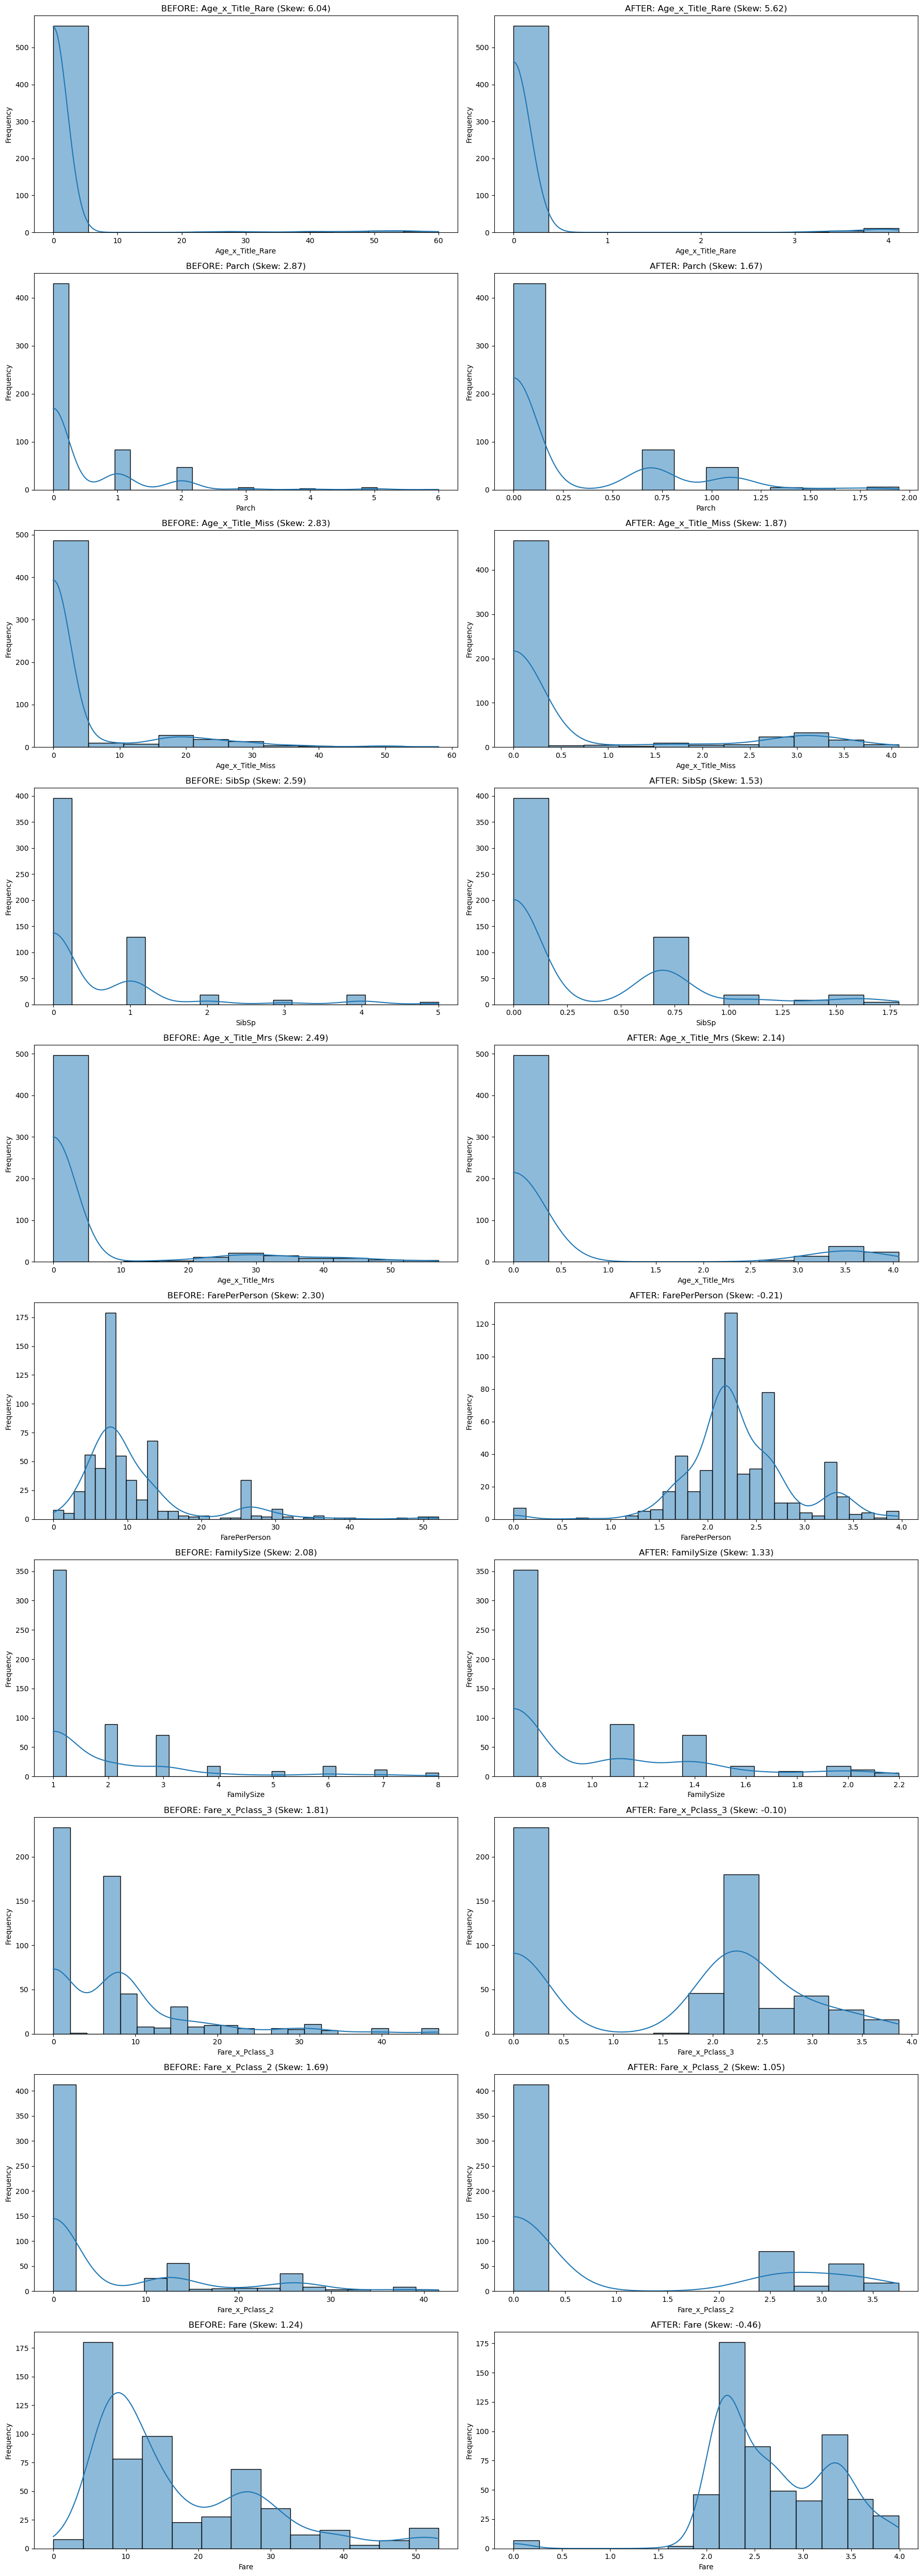

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# `train_csv_for_viz_before_transform` was created before log transformation in the previous cell.
# `train_csv_encoded` now contains the log-transformed data.

print("Visualizing distributions before and after Log1p Transformation...")

plt.figure(figsize=(18, 5 * len(skewed_features)))
for i, feature in enumerate(skewed_features):
    # Plot before transformation
    plt.subplot(len(skewed_features), 2, 2*i + 1)
    sns.histplot(train_csv_for_viz_before_transform[feature], kde=True)
    plt.title(f'BEFORE: {feature} (Skew: {train_csv_for_viz_before_transform[feature].skew():.2f})')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    # Plot after transformation
    plt.subplot(len(skewed_features), 2, 2*i + 2)
    sns.histplot(train_csv_encoded[feature], kde=True)
    plt.title(f'AFTER: {feature} (Skew: {train_csv_encoded[feature].skew():.2f})')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Applying Standardazation/ Scaling to Numerical Features 

In [32]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling
# Exclude 'PassengerId' and 'Survived' from scaling
columns_to_scale = [col for col in numerical_cols_present if col not in ['PassengerId', 'Survived']]

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected numerical columns in train_csv_encoded
train_csv_encoded[columns_to_scale] = scaler.fit_transform(train_csv_encoded[columns_to_scale])

print("Numerical features standardized successfully.")

# Display the head of the DataFrame with scaled features to confirm
print("\nHead of DataFrame with scaled numerical features:")
display(train_csv_encoded[columns_to_scale].head())

# Verify mean and standard deviation for a few scaled columns (should be close to 0 and 1 respectively)
print("\nMean and Std Dev for first 5 scaled numerical features (should be ~0 and ~1):")
display(train_csv_encoded[columns_to_scale].iloc[:, :5].agg(['mean', 'std']).T)

Numerical features standardized successfully.

Head of DataFrame with scaled numerical features:


,Age,Fare,SibSp,Parch,FamilySize,FarePerPerson,Fare_x_Pclass_2,Fare_x_Pclass_3,Age_x_Title_Miss,Age_x_Title_Mr,Age_x_Title_Mrs,Age_x_Title_Rare
0,-0.431951,-0.935043,0.912078,-0.542557,0.313183,-1.403471,-0.621246,0.488821,-0.459438,0.251254,-0.397561,-0.17407
2,-0.122814,-0.812007,-0.609149,-0.542557,-0.683596,-0.225283,-0.621246,0.550217,2.451526,-1.055100,-0.397561,-0.17407
3,0.572742,2.007153,0.912078,-0.542557,0.313183,1.794844,-0.621246,-1.158607,-0.459438,-1.055100,2.556397,-0.17407
4,0.572742,-0.790247,-0.609149,-0.542557,-0.683596,-0.200355,-0.621246,0.561075,-0.459438,1.023189,-0.397561,-0.17407
6,2.041140,1.970951,-0.609149,-0.542557,-0.683596,2.962838,-0.621246,-1.158607,-0.459438,2.151404,-0.397561,-0.17407



Mean and Std Dev for first 5 scaled numerical features (should be ~0 and ~1):


,mean,std
Age,1.235726e-16,1.000871
Fare,1.760910e-16,1.000871
SibSp,-4.325043e-17,1.000871
Parch,-6.024167e-17,1.000871
FamilySize,4.047004e-16,1.000871


Feature Selection  - Correlation Analysis

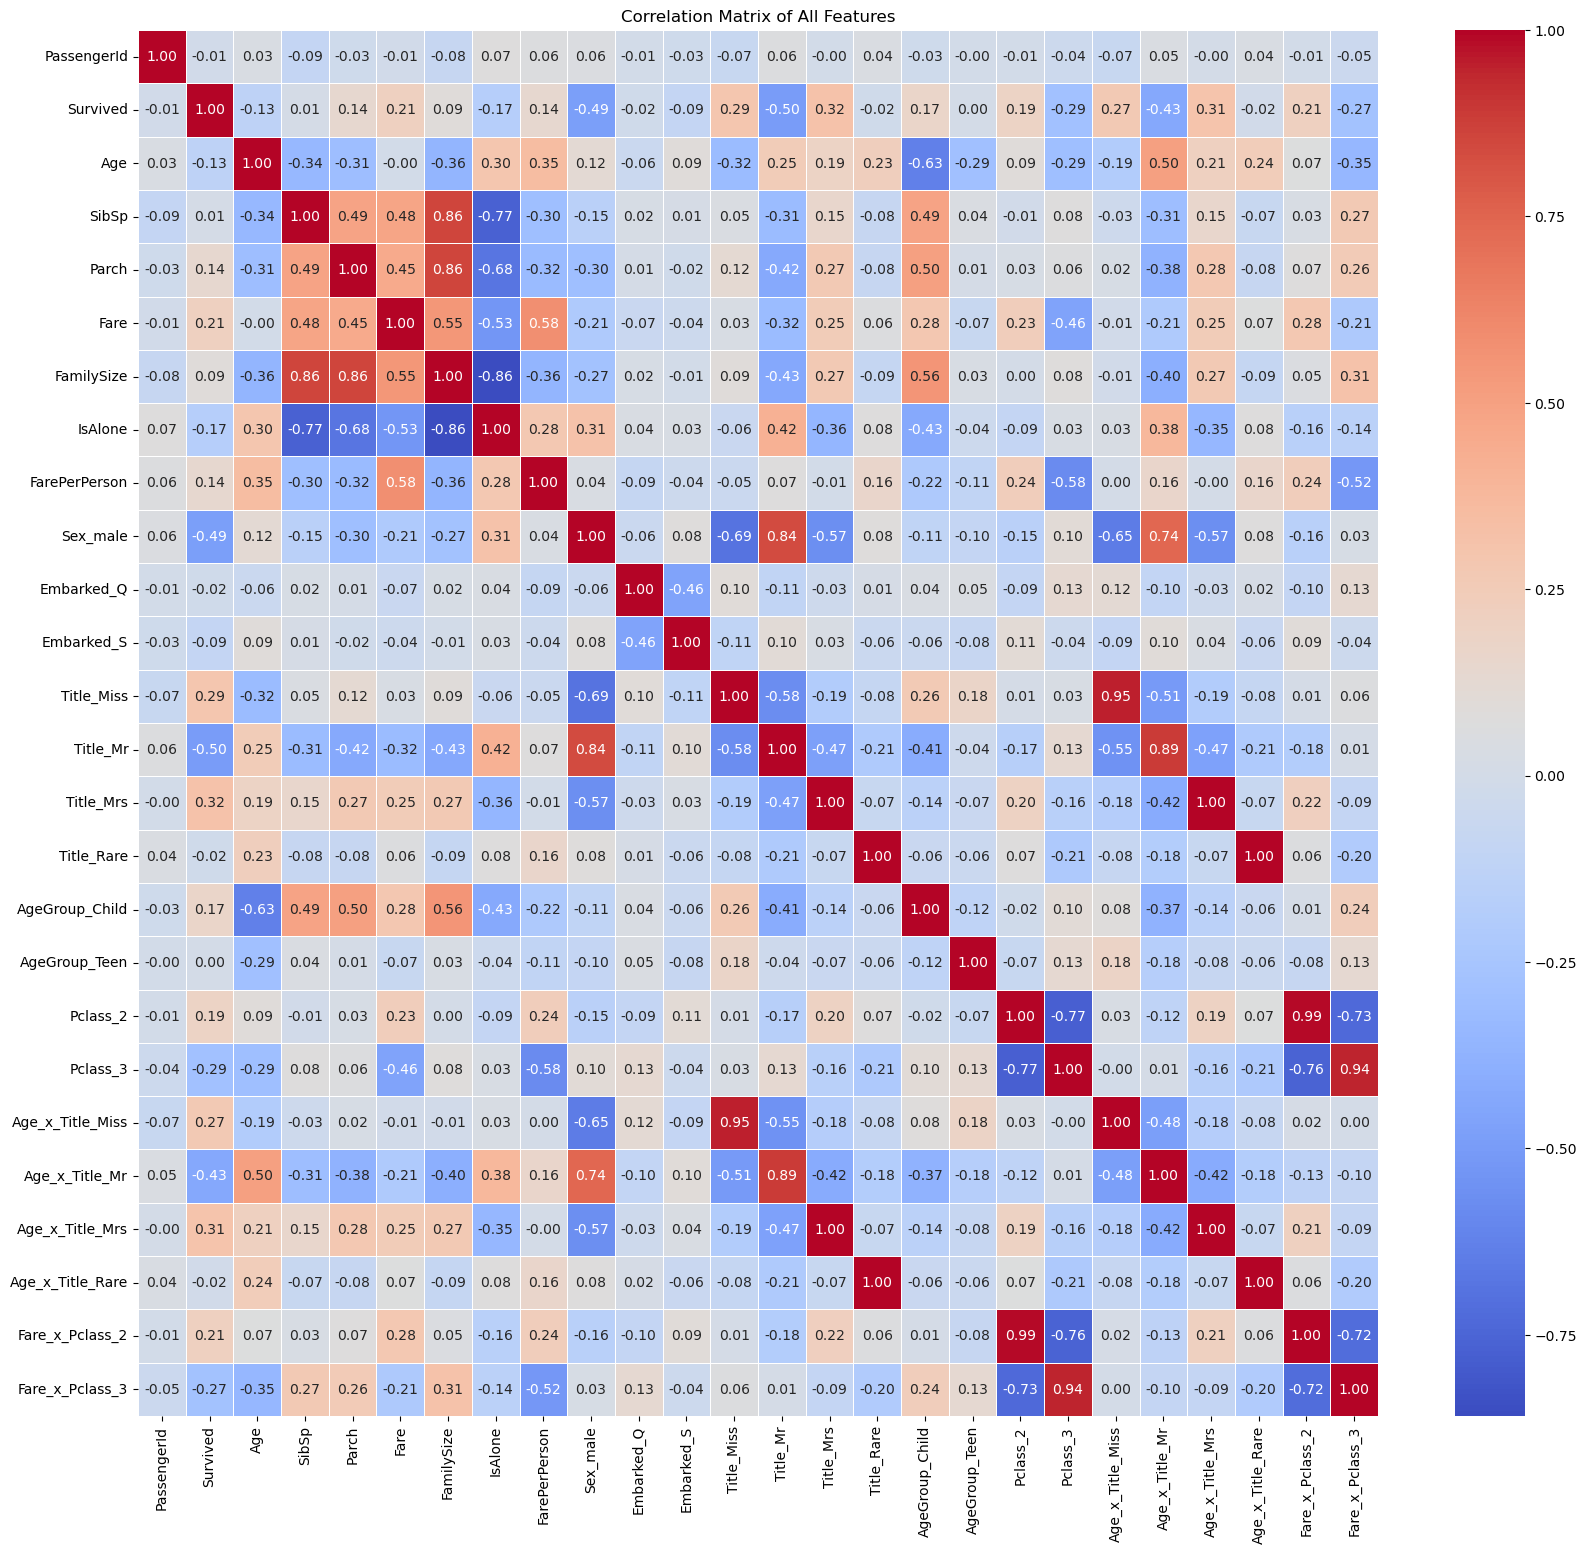


Highly correlated feature pairs (absolute correlation > 0.8):
- FamilySize and SibSp: 0.86
- FamilySize and Parch: 0.86
- IsAlone and FamilySize: -0.86
- Title_Mr and Sex_male: 0.84
- Age_x_Title_Miss and Title_Miss: 0.95
- Age_x_Title_Mr and Title_Mr: 0.89
- Age_x_Title_Mrs and Title_Mrs: 1.00
- Age_x_Title_Rare and Title_Rare: 1.00
- Fare_x_Pclass_2 and Pclass_2: 0.99
- Fare_x_Pclass_3 and Pclass_3: 0.94


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = train_csv_encoded.corr(numeric_only=True)

# Plotting the heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Features')
plt.show()

# Identify highly correlated feature pairs
# We want to find pairs with correlation above a certain threshold (e.g., 0.8 or 0.9)
correlation_threshold = 0.8

highly_correlated_pairs = []
# Iterate through the upper triangle of the correlation matrix to avoid duplicates and self-correlation
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > correlation_threshold:
            colname1 = correlation_matrix.columns[i]
            colname2 = correlation_matrix.columns[j]
            highly_correlated_pairs.append((colname1, colname2, correlation_matrix.iloc[i, j]))

# Print highly correlated pairs
if highly_correlated_pairs:
    print(f"\nHighly correlated feature pairs (absolute correlation > {correlation_threshold}):")
    for col1, col2, corr_val in highly_correlated_pairs:
        print(f"- {col1} and {col2}: {corr_val:.2f}")
else:
    print(f"\nNo highly correlated feature pairs found (absolute correlation > {correlation_threshold}).")

Feature Selection - Feature Importance

Non-numeric columns: ['Name', 'Ticket', 'Cabin']
Numeric columns only: ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeGroup_Child', 'AgeGroup_Teen', 'Pclass_2', 'Pclass_3', 'Age_x_Title_Miss', 'Age_x_Title_Mr', 'Age_x_Title_Mrs', 'Age_x_Title_Rare', 'Fare_x_Pclass_2', 'Fare_x_Pclass_3']
X_train shape: (460, 24)
X_test shape: (115, 24)

Top 10 Feature Importances:
Age_x_Title_Mr      0.142732
Age                 0.141365
FarePerPerson       0.107755
Fare                0.103051
Fare_x_Pclass_3     0.083134
Sex_male            0.059131
Title_Mr            0.047944
Age_x_Title_Miss    0.042988
Age_x_Title_Mrs     0.037017
Pclass_3            0.036151
dtype: float64


C:\Users\My PC\AppData\Local\Temp\ipykernel_1996\3907524562.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.head(20).values, y=feature_importances.head(20).index, palette='viridis')


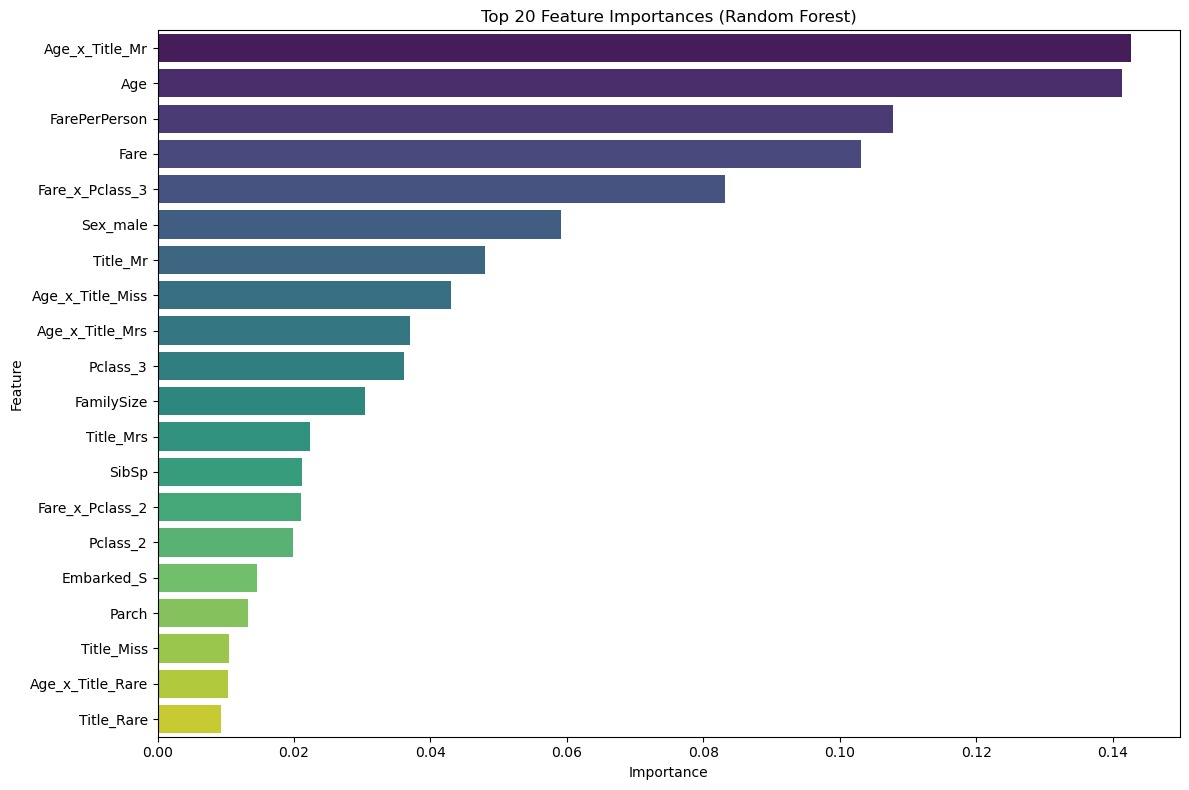

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# First, identify non-numeric columns
non_numeric_cols = train_csv_encoded.select_dtypes(include=['object', 'category']).columns.tolist()
print("Non-numeric columns:", non_numeric_cols)

# Option A: Drop non-numeric columns (simplest)
X = train_csv_encoded.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket'] + non_numeric_cols, errors='ignore')
y = train_csv_encoded['Survived']

print("Numeric columns only:", X.columns.tolist())

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get feature importances
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nTop 10 Feature Importances:")
print(feature_importances.head(10))

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances.head(20).values, y=feature_importances.head(20).index, palette='viridis')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Feature Selection - Recursive Feature Elimination (RFE)

In [41]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# Initialize a RandomForestClassifier as the estimator for RFE
# Using a small number of estimators for faster computation in RFE
estimator = RandomForestClassifier(n_estimators=50, random_state=42)

# Initialize RFE
# Select an arbitrary number of features to start, e.g., half of the current features
# You can adjust n_features_to_select based on further analysis or model performance
n_features_to_select = X_train.shape[1] // 2 # Select half of the current features
rfe_selector = RFE(estimator=estimator, n_features_to_select=n_features_to_select, step=1)

# Fit RFE to the training data
rfe_selector.fit(X_train, y_train)

# Get the selected features and their ranking
rfe_support = rfe_selector.get_support() # A boolean mask of selected features
rfe_ranking = rfe_selector.ranking_    # Feature ranks (1 being most important)

# Create a DataFrame for RFE results
rfe_results = pd.DataFrame({
    'Feature': X_train.columns,
    'Selected': rfe_support,
    'Ranking': rfe_ranking
})

print(f"RFE selected {n_features_to_select} features:")
selected_rfe_features = rfe_results[rfe_results['Selected'] == True].sort_values(by='Ranking')['Feature'].tolist()
print(selected_rfe_features)

print("\nFull RFE Ranking (1 = selected, higher numbers = less important and eliminated):")
display(rfe_results.sort_values(by='Ranking'))

RFE selected 12 features:
['Age', 'Fare', 'FamilySize', 'FarePerPerson', 'Sex_male', 'Title_Mr', 'Pclass_3', 'Age_x_Title_Miss', 'Age_x_Title_Mr', 'Age_x_Title_Mrs', 'Fare_x_Pclass_2', 'Fare_x_Pclass_3']

Full RFE Ranking (1 = selected, higher numbers = less important and eliminated):


,Feature,Selected,Ranking
0,Age,True,1
20,Age_x_Title_Mrs,True,1
19,Age_x_Title_Mr,True,1
18,Age_x_Title_Miss,True,1
17,Pclass_3,True,1
22,Fare_x_Pclass_2,True,1
7,Sex_male,True,1
11,Title_Mr,True,1
4,FamilySize,True,1
3,Fare,True,1
